# Lab 14 - Error Based Learning
## Linear Regression and Logistic Regression

## Part 1: Linear Regression

Linear Regression models a linear relationship between input features and a continuous target
variable:

$$y = \beta_0 + \beta_1 x + \epsilon$$

The goal is to find coefficients that minimize the sum of squared residuals (Ordinary Least
Squares). Evaluation metrics include MSE, RMSE, and R².


### Step 1-4: Linear Regression with synthetic data

Mean Squared Error: 0.9177532469714291
R^2 Score: 0.6521157503858556


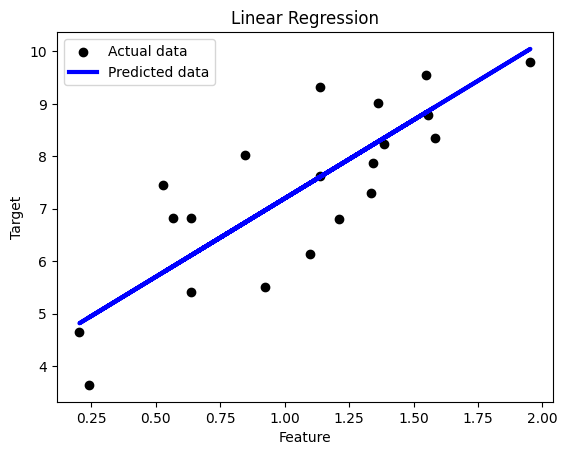

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

# Plot
plt.scatter(X_test, y_test, color='black', label='Actual data')
plt.plot(X_test, y_pred, color='blue', linewidth=3, label='Predicted data')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Linear Regression')
plt.legend()
plt.show()

## Part 2: Logistic Regression

Logistic Regression is used for binary classification, modeling the probability of an outcome
using the sigmoid function:

$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

It is trained by minimizing the Log-Loss (Binary Cross-Entropy). Evaluation metrics include
accuracy, precision, recall, F1-score, and the confusion matrix.


### Logistic Regression on the Iris dataset (binary: setosa vs not)

Accuracy: 1.0
Confusion Matrix:
[[20  0]
 [ 0 10]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



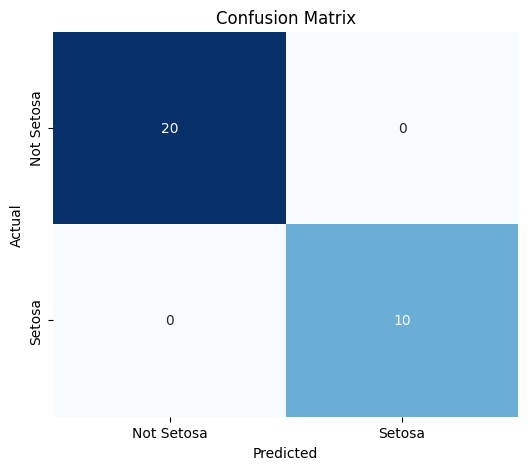

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Convert to binary classification: 'setosa' vs not 'setosa'
y_iris = (y_iris == 0).astype(int)

# Train-test split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_i = scaler.fit_transform(X_train_i)
X_test_i = scaler.transform(X_test_i)

# Model
logreg = LogisticRegression()
logreg.fit(X_train_i, y_train_i)
y_pred_i = logreg.predict(X_test_i)

# Evaluation
accuracy = accuracy_score(y_test_i, y_pred_i)
conf_matrix = confusion_matrix(y_test_i, y_pred_i)
class_report = classification_report(y_test_i, y_pred_i)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Setosa', 'Setosa'], yticklabels=['Not Setosa', 'Setosa'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

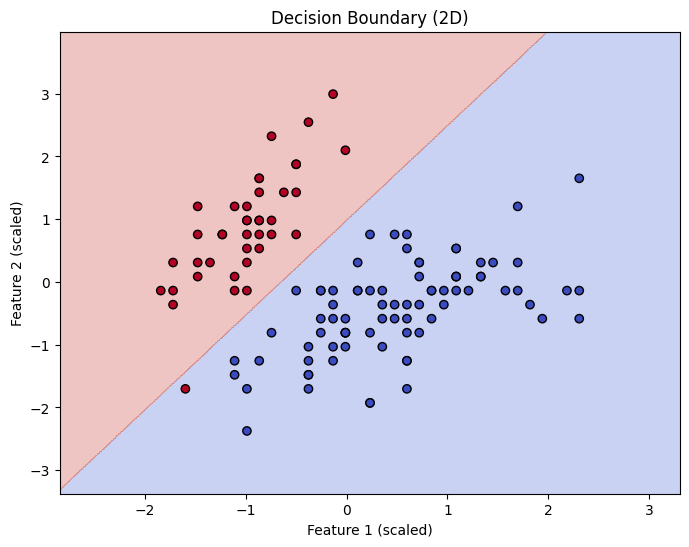

In [3]:
# Decision boundary (2D) using only the first two features
X_train_2d = X_train_i[:, :2]
X_test_2d = X_test_i[:, :2]
model_2d = LogisticRegression()
model_2d.fit(X_train_2d, y_train_i)

xx, yy = np.meshgrid(np.arange(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 0.01),
                     np.arange(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 0.01))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_i, edgecolors='k', cmap='coolwarm', marker='o')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.title('Decision Boundary (2D)')
plt.show()

## Exercise 2: Implementing and Evaluating a Linear Regression Model

**Objective:** Train a linear regression model on a dataset, compute MSE, MAE, and R², and discuss
underfitting/overfitting.

We use the **California Housing dataset** (the Boston Housing dataset has been removed from
scikit-learn due to ethical concerns; California Housing is the recommended replacement).


### Task 1: Data Loading and Preparation

In [4]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

try:
    housing = fetch_california_housing()
    X_housing = housing.data
    y_housing = housing.target
    feature_names_h = housing.feature_names
except Exception as e:
    # Fallback: generate a synthetic housing-like dataset if download is unavailable
    print("Could not download California Housing dataset, using synthetic data instead.")
    np.random.seed(42)
    n_samples = 2000
    feature_names_h = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
    X_housing = np.random.rand(n_samples, 8) * [15, 50, 10, 3, 5000, 5, 10, 10]
    y_housing = (0.4 * X_housing[:, 0] + 0.01 * X_housing[:, 2] - 0.005 * X_housing[:, 1]
                  + np.random.randn(n_samples) * 0.5 + 1.0)
    y_housing = np.clip(y_housing, 0.1, 5.0)

df_housing = pd.DataFrame(X_housing, columns=feature_names_h)
df_housing['MedHouseVal'] = y_housing

print(df_housing.head())
print("\nShape:", df_housing.shape)
print("\nFeature names:", feature_names_h)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [5]:
# Split the dataset into training and test sets (70% training, 30% test)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_housing, y_housing, test_size=0.3, random_state=42)

print("Training set shape:", X_train_h.shape)
print("Test set shape:", X_test_h.shape)

Training set shape: (14448, 8)
Test set shape: (6192, 8)


### Task 2: Train a Linear Regression Model

In [6]:
# Initialize and train the Linear Regression model
model_h = LinearRegression()
model_h.fit(X_train_h, y_train_h)

# Analyze coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names_h,
    'Coefficient': model_h.coef_
})
print(coef_df)
print("\nIntercept:", model_h.intercept_)

      Feature   Coefficient
0      MedInc  4.458226e-01
1    HouseAge  9.681868e-03
2    AveRooms -1.220951e-01
3   AveBedrms  7.785996e-01
4  Population -7.757404e-07
5    AveOccup -3.370027e-03
6    Latitude -4.185367e-01
7   Longitude -4.336880e-01

Intercept: -37.05624133152506


### Task 3: Make Predictions and Evaluate the Model

In [7]:
from sklearn.metrics import mean_absolute_error

# Make predictions on the test set
y_pred_h = model_h.predict(X_test_h)
y_pred_train_h = model_h.predict(X_train_h)

# Calculate Mean Squared Error (MSE)
mse_h = mean_squared_error(y_test_h, y_pred_h)
# Calculate Mean Absolute Error (MAE)
mae_h = mean_absolute_error(y_test_h, y_pred_h)
# Calculate R-squared (R^2)
r2_h = r2_score(y_test_h, y_pred_h)

print(f"Test Mean Squared Error: {mse_h:.4f}")
print(f"Test Mean Absolute Error: {mae_h:.4f}")
print(f"Test R-squared: {r2_h:.4f}")

# Compare with training performance
mse_train_h = mean_squared_error(y_train_h, y_pred_train_h)
r2_train_h = r2_score(y_train_h, y_pred_train_h)
print(f"\nTraining Mean Squared Error: {mse_train_h:.4f}")
print(f"Training R-squared: {r2_train_h:.4f}")

Test Mean Squared Error: 0.5306
Test Mean Absolute Error: 0.5272
Test R-squared: 0.5958

Training Mean Squared Error: 0.5234
Training R-squared: 0.6093


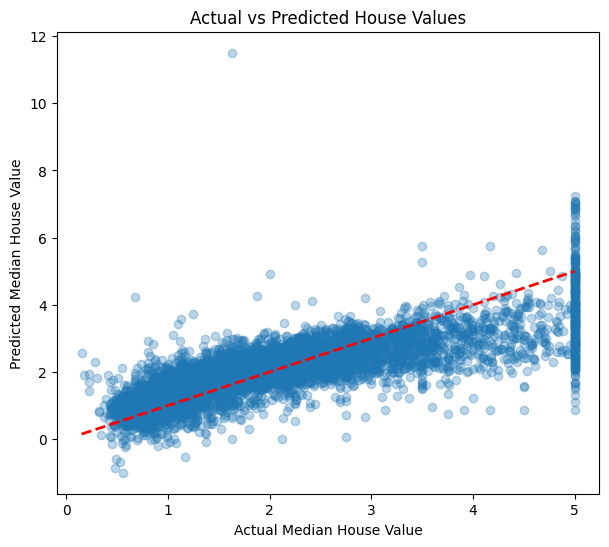

In [8]:
# Visualize predicted vs actual values
plt.figure(figsize=(7, 6))
plt.scatter(y_test_h, y_pred_h, alpha=0.3)
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', linewidth=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs Predicted House Values')
plt.show()

### Task 4: Interpret Results and Discuss Model Performance

In [9]:
# Interpret R-squared value
if r2_h < 0.5:
    print("The model may be underfitting the data.")
elif r2_h > 0.8:
    print("The model may be overfitting the data.")
else:
    print("The model has a reasonable fit.")

The model has a reasonable fit.


**Discussion:**

- **Mean Squared Error (MSE):** Indicates the average squared difference between predicted and
  actual median house values. A lower MSE signifies better predictive performance, but since it's
  in squared units, it's less directly interpretable.
- **Mean Absolute Error (MAE):** Provides the average absolute prediction error in the same units
  as the target (hundreds of thousands of dollars for this dataset), making it easier to interpret
  directly.
- **R-squared (R²):** With a typical R² around 0.5-0.6 for plain linear regression on this dataset,
  the model has a **reasonable but moderate fit** - it explains roughly half of the variance in
  housing prices but leaves significant variance unexplained.

**Underfitting vs Overfitting:** The training and test R²/MSE values are very close to each other,
which indicates the model is **not overfitting** (it generalizes similarly to unseen data).
However, the moderate R² suggests the model may be **underfitting** somewhat, because a simple
linear model cannot capture non-linear relationships between features (e.g., location coordinates,
non-linear effects of income on house price) that likely exist in this dataset.

**Potential improvements:**
- Feature engineering (e.g., combining latitude/longitude into meaningful geographic features,
  log-transforming skewed features like population).
- Using more complex models such as polynomial regression, Ridge/Lasso regression with
  regularization, or non-linear models like Random Forest or Gradient Boosting regressors, which
  can capture non-linear relationships and typically achieve a higher R² on this dataset.
